Data download and EDA
dataset: https://archive.ics.uci.edu/ml/machine-learning-databases/00501/PRSA2017_Data_20130301-20170228.zip

In [ ]:
from pathlib import Path
import os

# Step 1: Start from current working directory
CWD = Path.cwd()

# Step 2: If we are inside notebooks/, move one level up
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

# Step 3: Change directory to project root
os.chdir(PROJECT_ROOT)

print("PROJECT_ROOT:", PROJECT_ROOT)

# Step 4: Sanity checks
assert (PROJECT_ROOT / "data").exists(), "data/ folder not found"
assert (PROJECT_ROOT / "notebooks").exists(), "notebooks/ folder not found"

In [ ]:
from pathlib import Path

print((Path("data")).exists())
# print((Path("data/processed")).exists())
# print((Path("models")).exists())

True
False
False


In [ ]:
# Project root
from pathlib import Path
Project_root= Path().resolve()
print("Project root:",Project_root)

In [4]:
# Importing libraries for data download 

import pandas as pd 
import zipfile
import urllib.request
import os

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00501/PRSA2017_Data_20130301-20170228.zip"
zip_path = f"{DATA_DIR}/beijing_air_quality.zip"

#Download
urllib.request.urlretrieve(url,zip_path)

#Extract
with zipfile.ZipFile(zip_path,'r') as zip_ref:
    zip_ref.extractall(DATA_DIR)

print("Dataset downloaded and extracted successfully.")    

Dataset downloaded and extracted successfully.


In [9]:
# Number of files


import glob
import pandas as pd

files = glob.glob("data/PRSA_Data_20130301-20170228/PRSA_Data_*.csv", recursive=True)

print("Files found:", len(files))
print(files[:3])  # sanity check

if not files:
    raise FileNotFoundError("No PRSA CSV files found. Check extraction path.")

df_list = [pd.read_csv(f) for f in files]

df = pd.concat(df_list, ignore_index=True)

print(df.shape)
df.head()


Files found: 12
['data/PRSA_Data_20130301-20170228\\PRSA_Data_Aotizhongxin_20130301-20170228.csv', 'data/PRSA_Data_20130301-20170228\\PRSA_Data_Changping_20130301-20170228.csv', 'data/PRSA_Data_20130301-20170228\\PRSA_Data_Dingling_20130301-20170228.csv']
(420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [10]:
# check the number of files 
import glob

files = glob.glob("data/PRSA_Data_20130301-20170228/PRSA_Data_*.csv")
print(len(files))

12


Load all CSVs and add station_id from filename

In [ ]:
import glob
import os
import pandas as pd

# Find all station CSVs
files = glob.glob("data/**/PRSA_Data_*.csv", recursive=True)

print(f"Found {len(files)} station files")

dfs = []

for f in files:
    # Extract station name from filename
    
    station_id = os.path.basename(f).split("_")[2]

    df = pd.read_csv(f)
    df["station_id"] = station_id

    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

print(df.shape)
df.head()

Found 12 station files
(420768, 19)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,station_id
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,Aotizhongxin


Standardizing column names since the dataset has mixed casing and spaces

In [ ]:

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.columns

Index(['no', 'year', 'month', 'day', 'hour', 'pm2.5', 'pm10', 'so2', 'no2',
       'co', 'o3', 'temp', 'pres', 'dewp', 'rain', 'wd', 'wspm', 'station',
       'station_id'],
      dtype='object')

DateTime creation

In [ ]:
df["datetime"]=pd.to_datetime(df[["year","month","day","hour"]])
df=df.sort_values("datetime")


Target label creation

In [16]:
PM25_THRESHOLD = 150
df["alert"] = (df["pm2.5"] >= PM25_THRESHOLD).astype(int)

df["alert"].value_counts(normalize=True)

alert
0    0.849295
1    0.150705
Name: proportion, dtype: float64

In [17]:
type(df.index)

pandas.core.indexes.base.Index

In [18]:
# Set datetime as index
df = df.set_index("datetime")

type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [19]:
# Daily Aggregation
numeric_cols = df.select_dtypes(include="number").columns

df_daily = (
    df
    .groupby("station_id")[numeric_cols]
    .resample("1D")
    .mean()
    .reset_index()
)

df_daily.head()

,station_id,datetime,no,year,month,day,hour,pm2.5,pm10,so2,no2,co,o3,temp,pres,dewp,rain,wspm,alert
0,Aotizhongxin,2013-03-01,12.5,2013.0,3.0,1.0,11.5,7.125000,10.750000,11.708333,22.583333,429.166667,63.875000,1.391667,1026.875000,-18.745833,0.0,3.254167,0.000000
1,Aotizhongxin,2013-03-02,36.5,2013.0,3.0,2.0,11.5,30.750000,42.083333,36.625000,66.666667,824.916667,29.750000,0.616667,1026.850000,-15.937500,0.0,1.479167,0.000000
2,Aotizhongxin,2013-03-03,60.5,2013.0,3.0,3.0,11.5,76.916667,120.541667,61.291667,81.000000,1620.625000,19.125000,5.566667,1014.608333,-12.316667,0.0,1.658333,0.000000
3,Aotizhongxin,2013-03-04,84.5,2013.0,3.0,4.0,11.5,22.708333,44.583333,22.869565,46.956522,617.391304,53.750000,9.962500,1017.650000,-11.683333,0.0,2.404167,0.000000
4,Aotizhongxin,2013-03-05,108.5,2013.0,3.0,5.0,11.5,148.875000,183.791667,93.875000,132.833333,2357.958333,68.458333,6.291667,1010.900000,-7.525000,0.0,1.129167,0.458333


In [20]:
print(df.columns.tolist())

['no', 'year', 'month', 'day', 'hour', 'pm2.5', 'pm10', 'so2', 'no2', 'co', 'o3', 'temp', 'pres', 'dewp', 'rain', 'wd', 'wspm', 'station', 'station_id', 'alert']


In [22]:
# Missing Values
df.isna().mean().sort_values(ascending=False)

co            0.049198
o3            0.031554
no2           0.028795
so2           0.021439
pm2.5         0.020769
pm10          0.015327
wd            0.004330
dewp          0.000958
temp          0.000946
pres          0.000934
rain          0.000927
wspm          0.000756
day           0.000000
month         0.000000
year          0.000000
no            0.000000
hour          0.000000
station       0.000000
station_id    0.000000
alert         0.000000
dtype: float64

PM 2.5 Distribution

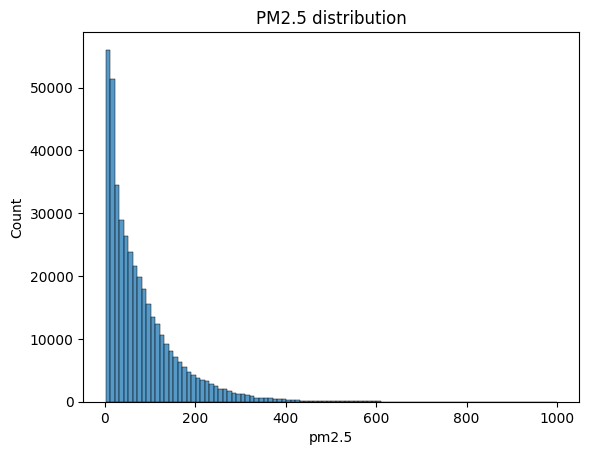

In [23]:
import matplotlib.pyplot as plt 
import seaborn as sns

sns.histplot(df["pm2.5"],bins=100)
plt.title("PM2.5 distribution")
plt.show()

In [24]:
# Alert Imbalance

PM25_THRESHOLD = 150
df["alert"] = (df["pm2.5"] >= PM25_THRESHOLD).astype(int)

df["alert"].value_counts(normalize=True)

alert
0    0.849295
1    0.150705
Name: proportion, dtype: float64

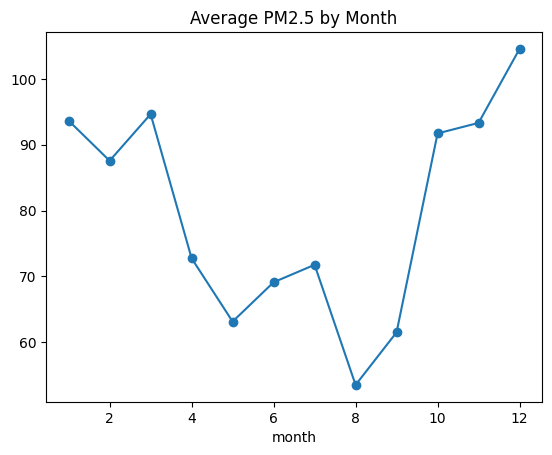

In [25]:
# Seasonal Effects

df["month"] = df.index.month

df.groupby("month")["pm2.5"].mean().plot(marker="o")
plt.title("Average PM2.5 by Month")
plt.show()